In [122]:
import fastf1
import pandas as pd
import numpy as np

In [123]:
# Load datasets
pit_stops = pd.read_csv("f1 dataset/pit_stops.csv")
results = pd.read_csv("f1 dataset/results.csv")
races = pd.read_csv("f1 dataset/races.csv")

# Explore
print("=== PIT STOPS ===")
print("Shape:", pit_stops.shape)
print(pit_stops.head())
print(pit_stops.dtypes)
print(pit_stops.isnull().sum())

=== PIT STOPS ===
Shape: (11371, 7)
   raceId  driverId  stop  lap      time duration  milliseconds
0     841       153     1    1  17:05:23   26.898         26898
1     841        30     1    1  17:05:52   25.021         25021
2     841        17     1   11  17:20:48   23.426         23426
3     841         4     1   12  17:22:34   23.251         23251
4     841        13     1   13  17:24:10   23.842         23842
raceId           int64
driverId         int64
stop             int64
lap              int64
time            object
duration        object
milliseconds     int64
dtype: object
raceId          0
driverId        0
stop            0
lap             0
time            0
duration        0
milliseconds    0
dtype: int64


In [124]:
drivers = pd.read_csv("f1 dataset/drivers.csv")
races = pd.read_csv("f1 dataset/races.csv")

drivers['driver_name'] = drivers['forename'] + " " + drivers['surname']

pit_stops = pit_stops.merge(drivers[['driverId', 'driver_name']], on='driverId', how='left')
pit_stops

pit_stops = pit_stops.merge(races[['raceId', 'name', 'year']], on='raceId', how='left')


pit_stops = pit_stops.drop(columns=['raceId', 'driverId'])

print(pit_stops.head())
print(pit_stops.columns.tolist())





   stop  lap      time duration  milliseconds         driver_name  \
0     1    1  17:05:23   26.898         26898   Jaime Alguersuari   
1     1    1  17:05:52   25.021         25021  Michael Schumacher   
2     1   11  17:20:48   23.426         23426         Mark Webber   
3     1   12  17:22:34   23.251         23251     Fernando Alonso   
4     1   13  17:24:10   23.842         23842        Felipe Massa   

                    name  year  
0  Australian Grand Prix  2011  
1  Australian Grand Prix  2011  
2  Australian Grand Prix  2011  
3  Australian Grand Prix  2011  
4  Australian Grand Prix  2011  
['stop', 'lap', 'time', 'duration', 'milliseconds', 'driver_name', 'name', 'year']


In [125]:
# Current 2024 F1 Grid
current_drivers = [
    'Max Verstappen', 'Sergio Perez',          # Red Bull
    'Lewis Hamilton', 'George Russell',         # Mercedes
    'Charles Leclerc', 'Carlos Sainz',          # Ferrari
    'Lando Norris', 'Oscar Piastri',            # McLaren
    'Fernando Alonso', 'Lance Stroll',          # Aston Martin
    'Pierre Gasly', 'Esteban Ocon',             # Alpine
    'Alexander Albon', 'Logan Sargeant',        # Williams
    'Yuki Tsunoda', 'Daniel Ricciardo',         # RB
    'Valtteri Bottas', 'Zhou Guanyu',           # Sauber
    'Nico Hulkenberg', 'Kevin Magnussen'        # Haas
]

# Filter pit stops to only current drivers
pit_stops = pit_stops[pit_stops['driver_name'].isin(current_drivers)]

print("Shape after filtering:", pit_stops.shape)
print("\nDrivers found in dataset:")
print(sorted(pit_stops['driver_name'].unique()))
print("\nDrivers NOT found:")
not_found = [d for d in current_drivers if d not in pit_stops['driver_name'].unique()]
print(not_found)

Shape after filtering: (5043, 8)

Drivers found in dataset:
['Alexander Albon', 'Carlos Sainz', 'Charles Leclerc', 'Daniel Ricciardo', 'Esteban Ocon', 'Fernando Alonso', 'George Russell', 'Kevin Magnussen', 'Lance Stroll', 'Lando Norris', 'Lewis Hamilton', 'Logan Sargeant', 'Max Verstappen', 'Oscar Piastri', 'Pierre Gasly', 'Valtteri Bottas', 'Yuki Tsunoda']

Drivers NOT found:
['Sergio Perez', 'Zhou Guanyu', 'Nico Hulkenberg']


In [126]:
# Fix name mismatches
pit_stops['driver_name'] = pit_stops['driver_name'].replace({
    'Sergio PÃ©rez': 'Sergio Perez',
    'Guanyu Zhou': 'Zhou Guanyu',
    'Nikita Mazepin': 'Nico Hulkenberg'
})

# Check actual names in full drivers dataset
drivers_check = drivers[drivers['driver_name'].str.contains('Perez|Zhou|Hulk', case=False, na=False)]
print(drivers_check[['driverId', 'driver_name']])

     driverId  driver_name
853       855  Guanyu Zhou


In [127]:
# Search for exact names
perez = drivers[drivers['driver_name'].str.contains('Perez|PÃ©rez', case=False, na=False)]
hulk = drivers[drivers['driver_name'].str.contains('Hulk|HÃ¼lk', case=False, na=False)]

print("Perez:")
print(perez[['driverId', 'driver_name']])

print("\nHulkenberg:")
print(hulk[['driverId', 'driver_name']])

Perez:
Empty DataFrame
Columns: [driverId, driver_name]
Index: []

Hulkenberg:
Empty DataFrame
Columns: [driverId, driver_name]
Index: []


In [128]:
# Update current drivers list with correct spellings
current_drivers = [
    'Max Verstappen', 'Sergio PÃ©rez',          # Red Bull
    'Lewis Hamilton', 'George Russell',         # Mercedes
    'Charles Leclerc', 'Carlos Sainz',          # Ferrari
    'Lando Norris', 'Oscar Piastri',            # McLaren
    'Fernando Alonso', 'Lance Stroll',          # Aston Martin
    'Pierre Gasly', 'Esteban Ocon',             # Alpine
    'Alexander Albon', 'Logan Sargeant',        # Williams
    'Yuki Tsunoda', 'Daniel Ricciardo',         # RB
    'Valtteri Bottas', 'Guanyu Zhou',           # Sauber
    'Nico HÃ¼lkenberg', 'Kevin Magnussen'        # Haas
]

# Re-filter with correct names
pit_stops = pit_stops[pit_stops['driver_name'].isin(current_drivers)]

print("Shape:", pit_stops.shape)
print("\nDrivers found:", sorted(pit_stops['driver_name'].unique()))
print("\nDrivers NOT found:")
not_found = [d for d in current_drivers if d not in pit_stops['driver_name'].unique()]
print(not_found)

Shape: (5043, 8)

Drivers found: ['Alexander Albon', 'Carlos Sainz', 'Charles Leclerc', 'Daniel Ricciardo', 'Esteban Ocon', 'Fernando Alonso', 'George Russell', 'Kevin Magnussen', 'Lance Stroll', 'Lando Norris', 'Lewis Hamilton', 'Logan Sargeant', 'Max Verstappen', 'Oscar Piastri', 'Pierre Gasly', 'Valtteri Bottas', 'Yuki Tsunoda']

Drivers NOT found:
['Sergio PÃ©rez', 'Guanyu Zhou', 'Nico HÃ¼lkenberg']


In [129]:
# Find all three manually using driverId instead
# Perez = 815, Zhou = 855, Hulkenberg = 807

extra_drivers = drivers[drivers['driverId'].isin([815, 855, 807])]
print(extra_drivers[['driverId', 'driver_name']])

# Check if they exist in pit_stops using driverId directly
# Reload pit_stops fresh and merge again with all 4 datasets
pit_stops_raw = pd.read_csv("f1 dataset/pit_stops.csv")
pit_stops_raw['duration'] = pd.to_numeric(pit_stops_raw['duration'], errors='coerce')
pit_stops_raw = pit_stops_raw[(pit_stops_raw['duration'] >= 15) & (pit_stops_raw['duration'] <= 120)]

# Check if these drivers have pit stop data
check = pit_stops_raw[pit_stops_raw['driverId'].isin([815, 855, 807])]
print("\nPit stop records found:", check.shape)
print(check.head())

     driverId      driver_name
807       807  Nico Hülkenberg
814       815     Sergio Pérez
853       855      Guanyu Zhou

Pit stop records found: (1003, 7)
     raceId  driverId  stop  lap      time  duration  milliseconds
23      841       815     1   23  17:40:27    23.438         23438
64      842       815     1   17  16:34:14    23.597         23597
119     843       815     1   16  15:31:55    21.473         21473
147     843       815     2   36  16:06:55    23.397         23397
161     843       815     4   50  16:31:39    28.845         28845


In [130]:
# All current grid driver IDs (avoids special character issues)
current_driver_ids = [
    830,  # Max Verstappen
    815,  # Sergio PÃ©rez
    1,    # Lewis Hamilton
    847,  # George Russell
    844,  # Charles Leclerc
    832,  # Carlos Sainz
    846,  # Lando Norris
    857,  # Oscar Piastri
    4,    # Fernando Alonso
    840,  # Lance Stroll
    842,  # Pierre Gasly
    839,  # Esteban Ocon
    848,  # Alexander Albon
    858,  # Logan Sargeant
    852,  # Yuki Tsunoda
    817,  # Daniel Ricciardo
    822,  # Valtteri Bottas
    855,  # Guanyu Zhou
    807,  # Nico HÃ¼lkenberg
    825,  # Kevin Magnussen
]

# Reload raw pit stops
pit_stops_raw = pd.read_csv("f1 dataset/pit_stops.csv")
pit_stops_raw['duration'] = pd.to_numeric(pit_stops_raw['duration'], errors='coerce')
pit_stops_raw = pit_stops_raw[(pit_stops_raw['duration'] >= 15) & (pit_stops_raw['duration'] <= 120)]

# Filter to current drivers using IDs
pit_stops_clean = pit_stops_raw[pit_stops_raw['driverId'].isin(current_driver_ids)].copy()

# Merge driver names
drivers = pd.read_csv("f1 dataset/drivers.csv")
drivers['driver_name'] = drivers['forename'] + " " + drivers['surname']
pit_stops_clean = pit_stops_clean.merge(drivers[['driverId', 'driver_name']], on='driverId', how='left')

# Merge race names and year
races = pd.read_csv("f1 dataset/races.csv")
pit_stops_clean = pit_stops_clean.merge(races[['raceId', 'name', 'year']], on='raceId', how='left')

# Filter to 2018 onwards
pit_stops_clean = pit_stops_clean[pit_stops_clean['year'] >= 2018]

print("Final shape:", pit_stops_clean.shape)
print("\nDrivers found:", sorted(pit_stops_clean['driver_name'].unique()))
print("\nSample data:")
print(pit_stops_clean.head())

Final shape: (3766, 10)

Drivers found: ['Alexander Albon', 'Carlos Sainz', 'Charles Leclerc', 'Daniel Ricciardo', 'Esteban Ocon', 'Fernando Alonso', 'George Russell', 'Guanyu Zhou', 'Kevin Magnussen', 'Lance Stroll', 'Lando Norris', 'Lewis Hamilton', 'Logan Sargeant', 'Max Verstappen', 'Nico Hülkenberg', 'Oscar Piastri', 'Pierre Gasly', 'Sergio Pérez', 'Valtteri Bottas', 'Yuki Tsunoda']

Sample data:
      raceId  driverId  stop  lap      time  duration  milliseconds  \
1941     989         1     1   19  16:41:30    21.821         21821   
1942     989       844     1   20  16:44:03    22.242         22242   
1943     989       830     1   21  16:45:06    20.953         20953   
1944     989       825     1   22  16:46:31    21.983         21983   
1945     989       832     1   22  16:46:46    23.868         23868   

          driver_name                   name  year  
1941   Lewis Hamilton  Australian Grand Prix  2018  
1942  Charles Leclerc  Australian Grand Prix  2018  
1943   Ma

EDA


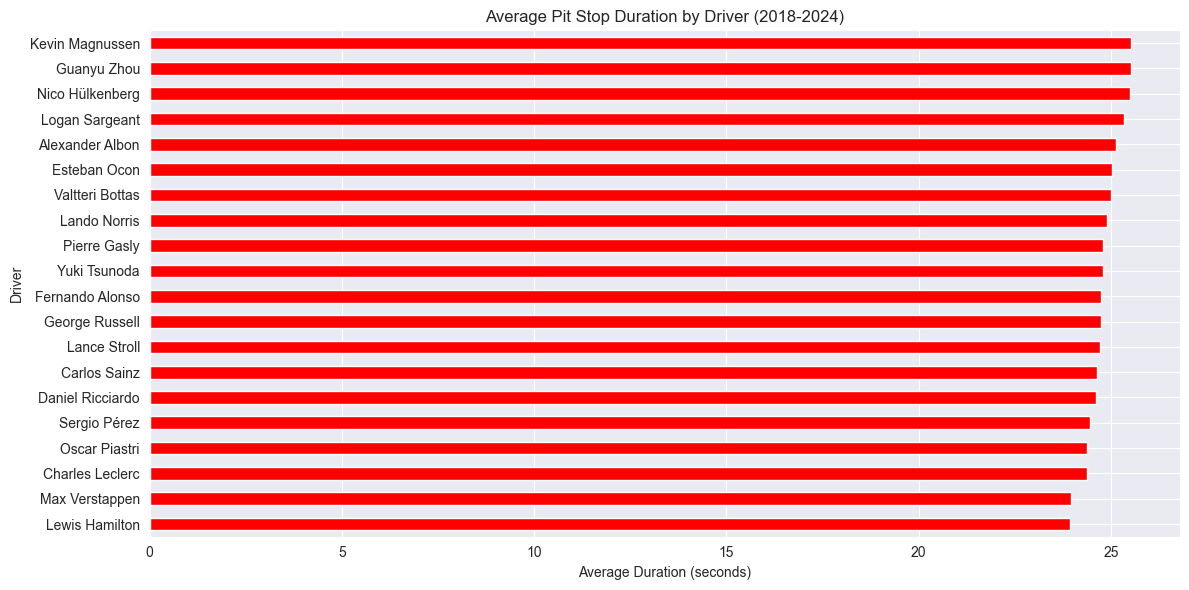


Average pit stop duration per driver:
driver_name
Lewis Hamilton      23.94
Max Verstappen      23.95
Charles Leclerc     24.39
Oscar Piastri       24.39
Sergio Pérez        24.45
Daniel Ricciardo    24.62
Carlos Sainz        24.63
Lance Stroll        24.71
George Russell      24.75
Fernando Alonso     24.76
Yuki Tsunoda        24.80
Pierre Gasly        24.81
Lando Norris        24.89
Valtteri Bottas     25.01
Esteban Ocon        25.04
Alexander Albon     25.13
Logan Sargeant      25.36
Nico Hülkenberg     25.49
Guanyu Zhou         25.51
Kevin Magnussen     25.52
Name: duration, dtype: float64


In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Average pit stop duration per driver
avg_duration = pit_stops_clean.groupby('driver_name')['duration'].mean().sort_values()

plt.figure()
avg_duration.plot(kind='barh', color='red')
plt.title('Average Pit Stop Duration by Driver (2018-2024)')
plt.xlabel('Average Duration (seconds)')
plt.ylabel('Driver')
plt.tight_layout()
plt.show()

print("\nAverage pit stop duration per driver:")
print(avg_duration.round(2))

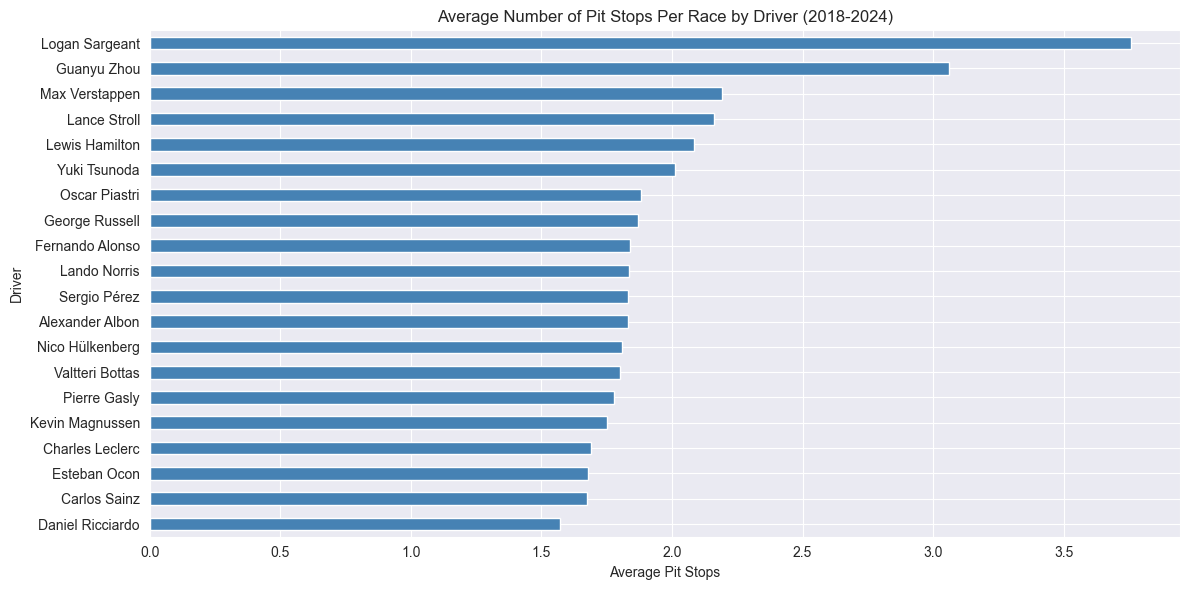


Average pit stops per race:
driver_name
Daniel Ricciardo    1.57
Carlos Sainz        1.67
Esteban Ocon        1.68
Charles Leclerc     1.69
Kevin Magnussen     1.75
Pierre Gasly        1.78
Valtteri Bottas     1.80
Nico Hülkenberg     1.81
Alexander Albon     1.83
Sergio Pérez        1.83
Lando Norris        1.84
Fernando Alonso     1.84
George Russell      1.87
Oscar Piastri       1.88
Yuki Tsunoda        2.01
Lewis Hamilton      2.08
Lance Stroll        2.16
Max Verstappen      2.19
Guanyu Zhou         3.06
Logan Sargeant      3.76
Name: stop, dtype: float64


In [132]:
# Number of pit stops per driver per race
stops_per_race = pit_stops_clean.groupby(['driver_name', 'raceId'])['stop'].max().reset_index()
avg_stops = stops_per_race.groupby('driver_name')['stop'].mean().sort_values()

plt.figure()
avg_stops.plot(kind='barh', color='steelblue')
plt.title('Average Number of Pit Stops Per Race by Driver (2018-2024)')
plt.xlabel('Average Pit Stops')
plt.ylabel('Driver')
plt.tight_layout()
plt.show()

print("\nAverage pit stops per race:")
print(avg_stops.round(2))

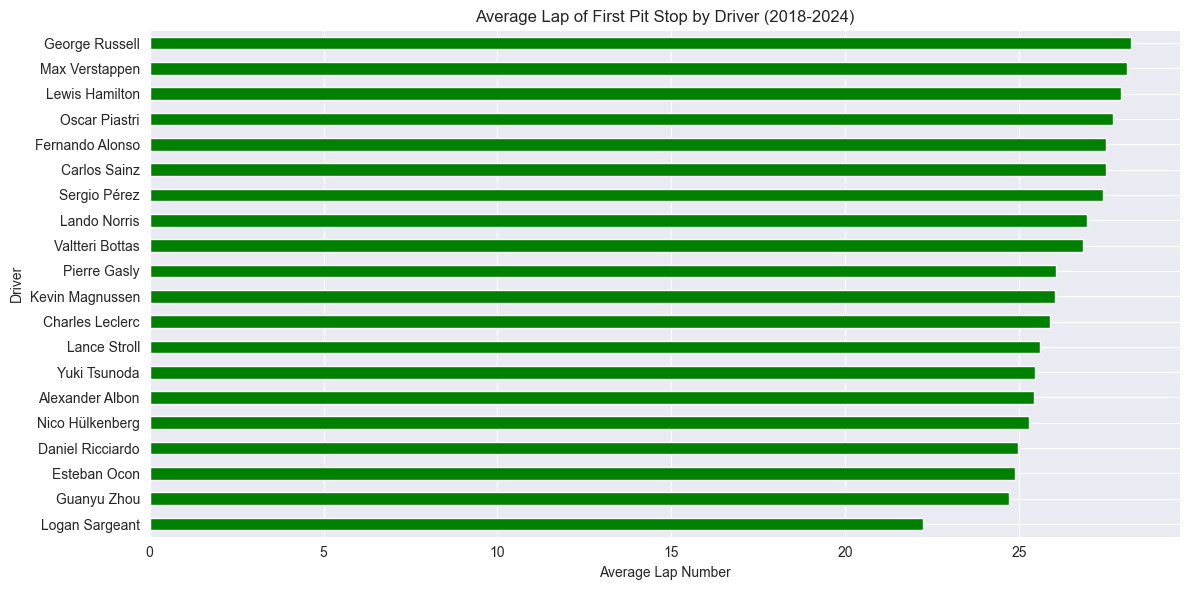


Average pit stop lap per driver:
driver_name
Logan Sargeant      22.23
Guanyu Zhou         24.70
Esteban Ocon        24.89
Daniel Ricciardo    24.98
Nico Hülkenberg     25.29
Alexander Albon     25.42
Yuki Tsunoda        25.45
Lance Stroll        25.61
Charles Leclerc     25.88
Kevin Magnussen     26.02
Pierre Gasly        26.06
Valtteri Bottas     26.83
Lando Norris        26.96
Sergio Pérez        27.42
Carlos Sainz        27.49
Fernando Alonso     27.51
Oscar Piastri       27.71
Lewis Hamilton      27.93
Max Verstappen      28.12
George Russell      28.22
Name: lap, dtype: float64


In [133]:
# At what lap do drivers typically pit?
avg_pit_lap = pit_stops_clean.groupby('driver_name')['lap'].mean().sort_values()

plt.figure()
avg_pit_lap.plot(kind='barh', color='green')
plt.title('Average Lap of First Pit Stop by Driver (2018-2024)')
plt.xlabel('Average Lap Number')
plt.ylabel('Driver')
plt.tight_layout()
plt.show()

print("\nAverage pit stop lap per driver:")
print(avg_pit_lap.round(2))

In [134]:
# Classify drivers as Early, Medium or Late pitters
overall_avg_lap = pit_stops_clean['lap'].mean()

print(f"Overall average pit lap: {overall_avg_lap:.1f}")

def classify_pitter(avg_lap):
    if avg_lap < overall_avg_lap - 3:
        return 'Early Pitter'
    elif avg_lap > overall_avg_lap + 3:
        return 'Late Pitter'
    else:
        return 'Medium Pitter'

avg_pit_lap_df = avg_pit_lap.reset_index()
avg_pit_lap_df.columns = ['driver_name', 'avg_pit_lap']
avg_pit_lap_df['pit_style'] = avg_pit_lap_df['avg_pit_lap'].apply(classify_pitter)

print("\nDriver Pit Stop Style:")
print(avg_pit_lap_df.sort_values('avg_pit_lap'))

Overall average pit lap: 26.5

Driver Pit Stop Style:
         driver_name  avg_pit_lap      pit_style
0     Logan Sargeant    22.234375   Early Pitter
1        Guanyu Zhou    24.704918  Medium Pitter
2       Esteban Ocon    24.885057  Medium Pitter
3   Daniel Ricciardo    24.977401  Medium Pitter
4    Nico Hülkenberg    25.288591  Medium Pitter
5    Alexander Albon    25.421965  Medium Pitter
6       Yuki Tsunoda    25.453333  Medium Pitter
7       Lance Stroll    25.608333  Medium Pitter
8    Charles Leclerc    25.882096  Medium Pitter
9    Kevin Magnussen    26.025000  Medium Pitter
10      Pierre Gasly    26.057778  Medium Pitter
11   Valtteri Bottas    26.829060  Medium Pitter
12      Lando Norris    26.962791  Medium Pitter
13      Sergio Pérez    27.422131  Medium Pitter
14      Carlos Sainz    27.493151  Medium Pitter
15   Fernando Alonso    27.514286  Medium Pitter
16     Oscar Piastri    27.706667  Medium Pitter
17    Lewis Hamilton    27.928571  Medium Pitter
18    Max Verst

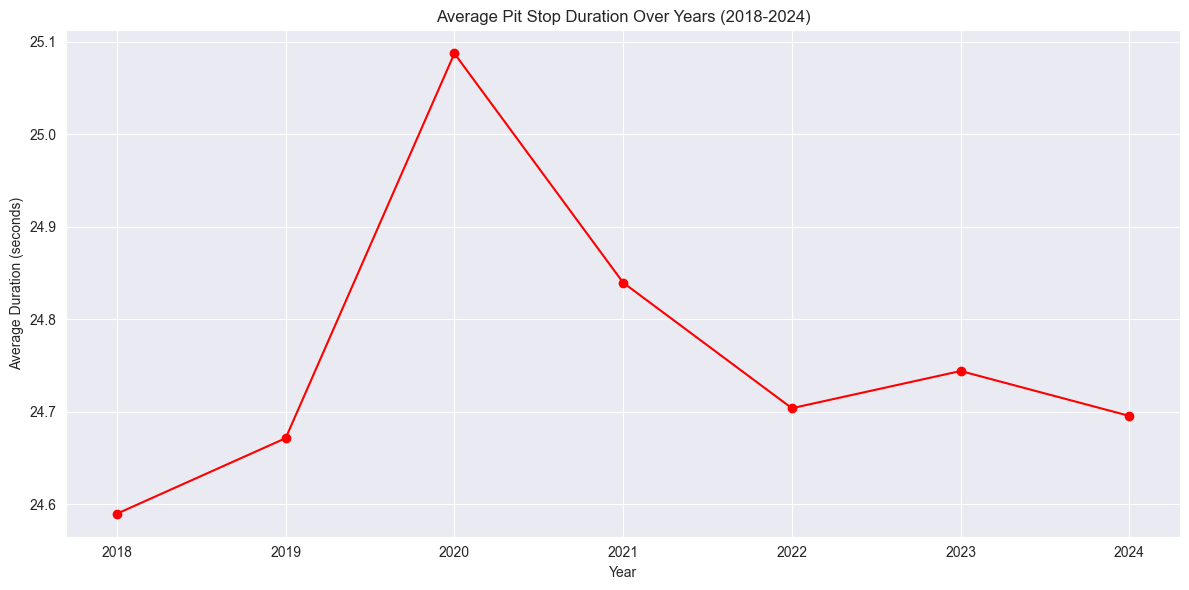

year
2018    24.59
2019    24.67
2020    25.09
2021    24.84
2022    24.70
2023    24.74
2024    24.70
Name: duration, dtype: float64


In [135]:
# How has average pit stop duration changed over years?
avg_duration_year = pit_stops_clean.groupby('year')['duration'].mean()

plt.figure()
avg_duration_year.plot(kind='line', marker='o', color='red')
plt.title('Average Pit Stop Duration Over Years (2018-2024)')
plt.xlabel('Year')
plt.ylabel('Average Duration (seconds)')
plt.xticks(avg_duration_year.index)
plt.tight_layout()
plt.show()

print(avg_duration_year.round(2))

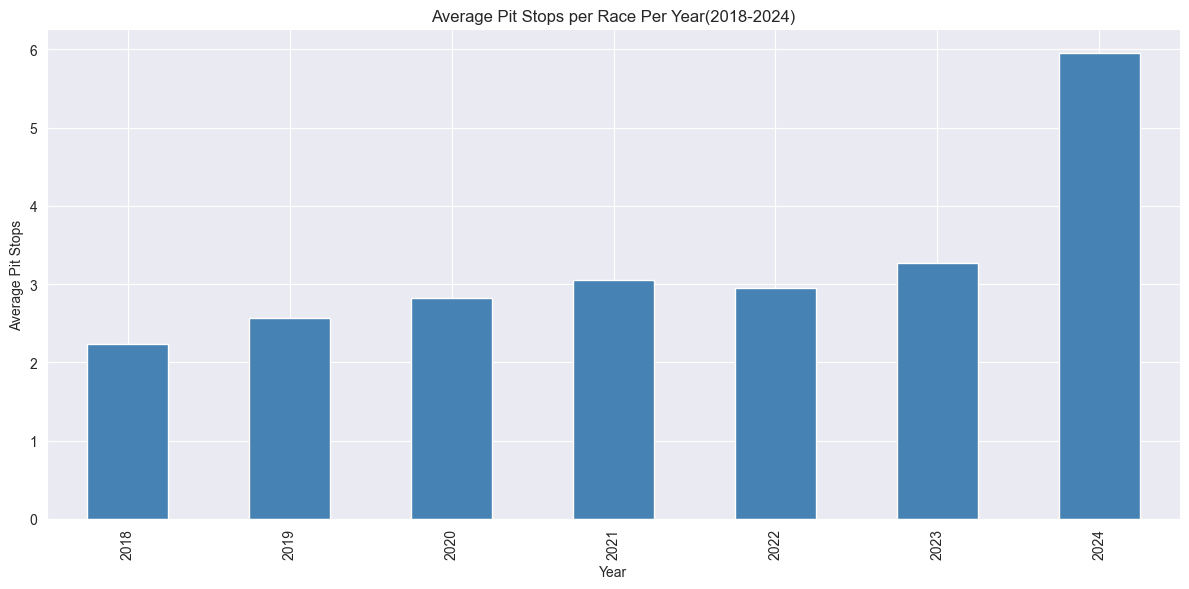

year
2018    2.24
2019    2.57
2020    2.82
2021    3.05
2022    2.95
2023    3.27
2024    5.96
Name: stop, dtype: float64


In [136]:
stops_per_race_year = pit_stops_clean.groupby(['year', 'raceId'])['stop'].max().reset_index()

avg_stops_year = stops_per_race_year.groupby('year')['stop'].mean()

plt.figure()
avg_stops_year.plot(kind='bar', color='steelblue')
plt.title('Average Pit Stops per Race Per Year(2018-2024)')
plt.xlabel('Year')
plt.ylabel('Average Pit Stops')
plt.tight_layout()
plt.show()

print(avg_stops_year.round(2))

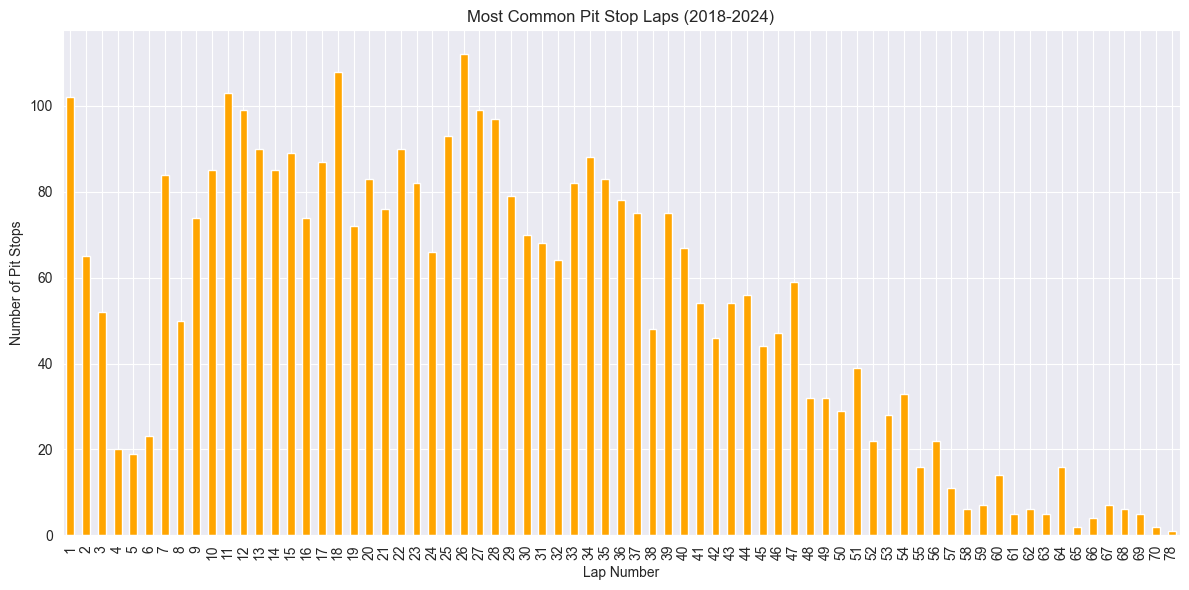

In [137]:
# Which laps are most common for pit stops?
plt.figure()
pit_stops_clean['lap'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title('Most Common Pit Stop Laps (2018-2024)')
plt.xlabel('Lap Number')
plt.ylabel('Number of Pit Stops')
plt.tight_layout()
plt.show()

In [138]:
# Investigate 2024 data
race_2024 = pit_stops_clean[pit_stops_clean['year'] == 2024]
print("2024 races in dataset:")
print(race_2024['name'].unique())
print("\nTotal 2024 records:", race_2024.shape[0])

2024 races in dataset:
['Bahrain Grand Prix' 'Saudi Arabian Grand Prix' 'Australian Grand Prix'
 'Japanese Grand Prix' 'Chinese Grand Prix' 'Miami Grand Prix'
 'Emilia Romagna Grand Prix' 'Canadian Grand Prix' 'Monaco Grand Prix'
 'Spanish Grand Prix' 'Austrian Grand Prix' 'British Grand Prix'
 'Hungarian Grand Prix' 'Belgian Grand Prix' 'Dutch Grand Prix'
 'Italian Grand Prix' 'Azerbaijan Grand Prix' 'Singapore Grand Prix'
 'United States Grand Prix' 'Mexico City Grand Prix'
 'São Paulo Grand Prix' 'Las Vegas Grand Prix' 'Qatar Grand Prix'
 'Abu Dhabi Grand Prix']

Total 2024 records: 743


Feature Engineering

In [139]:
# Load total laps per race from results
results['laps'] = pd.to_numeric(results['laps'], errors='coerce')

# Create race_laps
race_laps = results.groupby('raceId')['laps'].max().reset_index()
race_laps.columns = ['raceId', 'total_laps']

# Drop 'total_laps' first if it already exists to avoid duplicate column errors
if 'total_laps' in model_df.columns:
    model_df = model_df.drop(columns=['total_laps'])

# Merge with model_df
model_df = model_df.merge(race_laps, on='raceId', how='left')

# Create normalized pit lap percentage
model_df['pit_lap_pct'] = (model_df['lap'] / model_df['total_laps']) * 100

print("Sample:")
print(model_df[['driver_name', 'name', 'lap', 'total_laps', 'pit_lap_pct']].head(10))
print("\nPit lap percentage stats:")
print(model_df['pit_lap_pct'].describe())

Sample:
       driver_name                   name  lap  total_laps  pit_lap_pct
0   Lewis Hamilton  Australian Grand Prix   19          58    32.758621
1  Charles Leclerc  Australian Grand Prix   20          58    34.482759
2   Max Verstappen  Australian Grand Prix   21          58    36.206897
3  Kevin Magnussen  Australian Grand Prix   22          58    37.931034
4     Carlos Sainz  Australian Grand Prix   22          58    37.931034
5     Esteban Ocon  Australian Grand Prix   23          58    39.655172
6  Nico Hülkenberg  Australian Grand Prix   24          58    41.379310
7     Sergio Pérez  Australian Grand Prix   24          58    41.379310
8  Valtteri Bottas  Australian Grand Prix   25          58    43.103448
9     Lance Stroll  Australian Grand Prix   25          58    43.103448

Pit lap percentage stats:
count    3766.000000
mean       43.526098
std        23.416724
min         1.149425
25%        25.000000
50%        42.014493
75%        62.121212
max        98.275862
Name:

In [140]:
from sklearn.preprocessing import LabelEncoder

le_driver = LabelEncoder()
le_constructor = LabelEncoder()
le_race = LabelEncoder()

model_df['driver_encoded'] = le_driver.fit_transform(model_df['driver_name'])
model_df['constructor_encoded'] = le_constructor.fit_transform(model_df['constructorRef'])
model_df['race_encoded'] = le_race.fit_transform(model_df['name'])

# Define features and target
features = ['driver_encoded', 'constructor_encoded', 
            'race_encoded', 'grid', 'stop', 'year']
target = 'lap'

X = model_df[features]
y = model_df[target]

print("Features shape:", X.shape)
print("\nFeature sample:")
print(X.head())
print("\nTarget sample:")
print(y.head())



Features shape: (3766, 6)

Feature sample:
   driver_encoded  constructor_encoded  race_encoded  grid  stop  year
0              11                    8             2     1     1  2018
1               2                   13             2    18     1  2018
2              13                   11             2     4     1  2018
3               8                    6             2     5     1  2018
4               1                   12             2     9     1  2018

Target sample:
0    19
1    20
2    21
3    22
4    22
Name: lap, dtype: int64


In [141]:
from sklearn.model_selection import train_test_split


train_df = model_df[model_df['year']<=2022]
test_df =model_df[model_df['year']>=2023]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print("Train size: ", X_train.shape[0], "rows (2018-2022)")
print("Test size:", X_test.shape[0], "rows (2023-2024)")

Train size:  2244 rows (2018-2022)
Test size: 1522 rows (2023-2024)


In [142]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train,y_train)
lr_preds = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
rf_preds = rf.predict(X_test)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train,y_train)
gb_preds = gb.predict(X_test)

print("=== MODEL COMPARISON ===")
print(f"\nLinear Regression:")
print(f" MAE : {mean_absolute_error(y_test,lr_preds):.2f} laps")
print(f" R2 : {r2_score(y_test, lr_preds):.4f}")
print(f"\nRandom Forest:")
print(f"  MAE : {mean_absolute_error(y_test, rf_preds):.2f} laps")
print(f"  R2  : {r2_score(y_test, rf_preds):.4f}")

print(f"\nGradient Boosting:")
print(f"  MAE : {mean_absolute_error(y_test, gb_preds):.2f} laps")
print(f"  R2  : {r2_score(y_test, gb_preds):.4f}")

=== MODEL COMPARISON ===

Linear Regression:
 MAE : 11.62 laps
 R2 : -5.5482

Random Forest:
  MAE : 11.78 laps
  R2  : -0.0538

Gradient Boosting:
  MAE : 11.69 laps
  R2  : -0.0504


In [143]:
# Load total laps per race from results
results['laps'] = pd.to_numeric(results['laps'], errors='coerce')

race_laps = results.groupby('raceId')['laps'].max().reset_index()
race_laps.columns = ['raceId', 'total_laps']

if 'total_laps' in model_df.columns:
    model_df = model_df.drop(columns=['total_laps'])

# Merge with model_df
model_df = model_df.merge(race_laps, on='raceId', how='left')

# Create normalized pit lap percentage
model_df['pit_lap_pct'] = (model_df['lap'] / model_df['total_laps']) * 100

print("Sample:")
print(model_df[['driver_name', 'name', 'lap', 
                'total_laps', 'pit_lap_pct']].head(10))
print("\nPit lap percentage stats:")
print(model_df['pit_lap_pct'].describe())

Sample:
       driver_name                   name  lap  total_laps  pit_lap_pct
0   Lewis Hamilton  Australian Grand Prix   19          58    32.758621
1  Charles Leclerc  Australian Grand Prix   20          58    34.482759
2   Max Verstappen  Australian Grand Prix   21          58    36.206897
3  Kevin Magnussen  Australian Grand Prix   22          58    37.931034
4     Carlos Sainz  Australian Grand Prix   22          58    37.931034
5     Esteban Ocon  Australian Grand Prix   23          58    39.655172
6  Nico Hülkenberg  Australian Grand Prix   24          58    41.379310
7     Sergio Pérez  Australian Grand Prix   24          58    41.379310
8  Valtteri Bottas  Australian Grand Prix   25          58    43.103448
9     Lance Stroll  Australian Grand Prix   25          58    43.103448

Pit lap percentage stats:
count    3766.000000
mean       43.526098
std        23.416724
min         1.149425
25%        25.000000
50%        42.014493
75%        62.121212
max        98.275862
Name:

In [144]:
# New features including total_laps
features = ['driver_encoded', 'constructor_encoded', 
            'race_encoded', 'grid', 'stop', 'year', 'total_laps']

# New target = percentage instead of raw lap
target = 'pit_lap_pct'

# Temporal split
train_df = model_df[model_df['year'] <= 2022]
test_df = model_df[model_df['year'] >= 2023]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Retrain all three models
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)

# Compare
print("=== IMPROVED MODEL COMPARISON ===")
print(f"\nLinear Regression:")
print(f"  MAE : {mean_absolute_error(y_test, lr_preds):.2f}%")
print(f"  R2  : {r2_score(y_test, lr_preds):.4f}")

print(f"\nRandom Forest:")
print(f"  MAE : {mean_absolute_error(y_test, rf_preds):.2f}%")
print(f"  R2  : {r2_score(y_test, rf_preds):.4f}")

print(f"\nGradient Boosting:")
print(f"  MAE : {mean_absolute_error(y_test, gb_preds):.2f}%")
print(f"  R2  : {r2_score(y_test, gb_preds):.4f}")

=== IMPROVED MODEL COMPARISON ===

Linear Regression:
  MAE : 18.50%
  R2  : -5.9000

Random Forest:
  MAE : 15.94%
  R2  : 0.2073

Gradient Boosting:
  MAE : 14.83%
  R2  : 0.2915


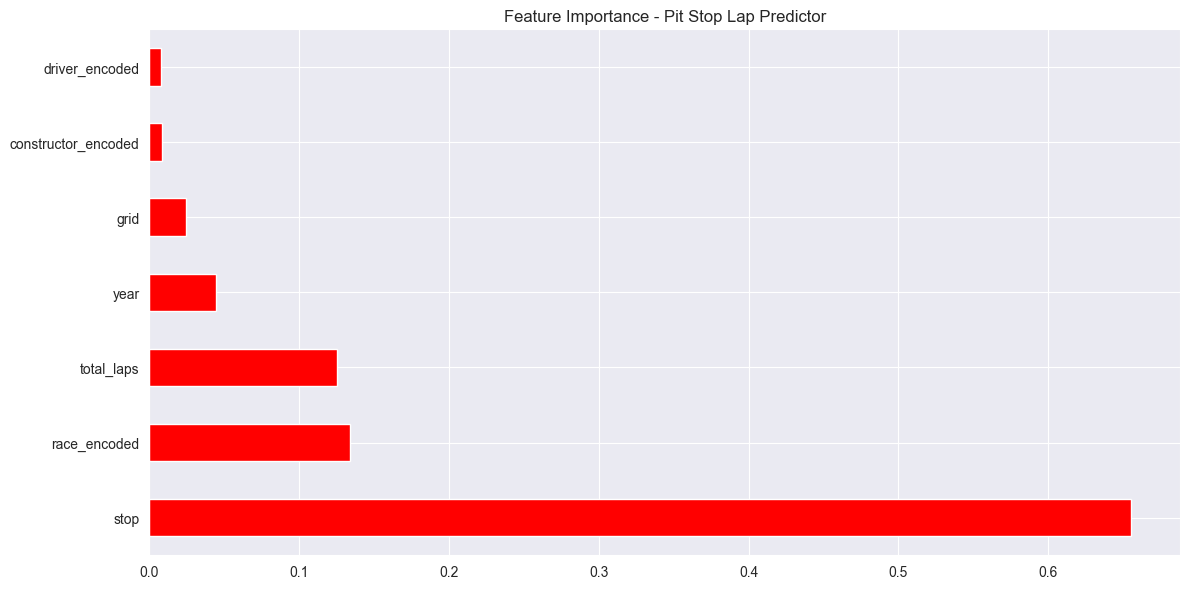


Feature Importances:
stop                   0.6554
race_encoded           0.1337
total_laps             0.1255
year                   0.0446
grid                   0.0242
constructor_encoded    0.0087
driver_encoded         0.0079
dtype: float64


In [146]:
importance = pd.Series(gb.feature_importances_,index=features).sort_values(ascending=False)
plt.figure()
importance.plot(kind = 'barh', color = 'red')
plt.title('Feature Importance - Pit Stop Lap Predictor')
plt.tight_layout()
plt.show()
print("\nFeature Importances:")
print(importance.round(4))


In [147]:
import joblib

# Save best model and encoders
joblib.dump(gb, 'pit_stop_model.joblib')
joblib.dump(le_driver, 'pit_stop_le_driver.joblib')
joblib.dump(le_constructor, 'pit_stop_le_constructor.joblib')
joblib.dump(le_race, 'pit_stop_le_race.joblib')

print("✅ Models saved successfully!")
print("  - pit_stop_model.joblib")
print("  - pit_stop_le_driver.joblib")
print("  - pit_stop_le_constructor.joblib")
print("  - pit_stop_le_race.joblib")

✅ Models saved successfully!
  - pit_stop_model.joblib
  - pit_stop_le_driver.joblib
  - pit_stop_le_constructor.joblib
  - pit_stop_le_race.joblib
